In [ ]:
!pip install scikit-learn xgboost pandas numpy matplotlib seaborn tabulate -q

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
CSV_PATH = '/content/hrv_features_dataset.csv'  # <-- change if your file is named/located differently

full_df = pd.read_csv(CSV_PATH)

meta_cols = ['record_id', 'window_end_sec', 'label']
feature_cols = [c for c in full_df.columns if c not in meta_cols]

print("Dataset shape:", full_df.shape)
print("Class balance:\n", full_df['label'].value_counts())
print("Unique patients:", full_df['record_id'].nunique())

Dataset shape: (12205, 98)
Class balance:
 label
0    11850
1      355
Name: count, dtype: int64
Unique patients: 30


In [ ]:
nan_frac = full_df[feature_cols].isna().mean()
keep_cols = nan_frac[nan_frac < 0.2].index.tolist()
full_df = full_df.dropna(subset=keep_cols)

print(f"Using {len(keep_cols)} of {len(feature_cols)} features")
print("Dataset shape after cleaning:", full_df.shape)

Using 90 of 95 features
Dataset shape after cleaning: (12205, 98)


In [ ]:
# Undersample the majority (Normal) class so it matches the minority (Pre-arrest)
# class count. This gives you a 50/50 training set instead of the ~97/3 split you
# had before, which is what let the model default to "always predict normal."
BALANCE_STRATEGY = 'undersample'  # 'undersample' = drop excess Normal rows to match Pre-arrest count

pre_arrest_df = full_df[full_df['label'] == 1]
normal_df = full_df[full_df['label'] == 0]

print(f"Before balancing — Normal: {len(normal_df)}, Pre-arrest: {len(pre_arrest_df)}")

normal_df_balanced = normal_df.sample(n=len(pre_arrest_df), random_state=RANDOM_STATE)
full_df = pd.concat([pre_arrest_df, normal_df_balanced], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # shuffle

print(f"After balancing — Normal: {sum(full_df['label']==0)}, Pre-arrest: {sum(full_df['label']==1)}")
print("Patients remaining:", full_df['record_id'].nunique())

Before balancing — Normal: 11850, Pre-arrest: 355
After balancing — Normal: 355, Pre-arrest: 355
Patients remaining: 25


In [ ]:
X = full_df[keep_cols]
y = full_df['label'].astype(int)
groups = full_df['record_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train windows:", X_train.shape, " Test windows:", X_test.shape)
print("Train patients:", groups_train.nunique(), " Test patients:", groups.iloc[test_idx].nunique())

Train windows: (528, 90)  Test windows: (182, 90)
Train patients: 18  Test patients: 7


In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (class ratio) = {scale_pos_weight:.1f}")

candidate_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    "SVM_RBF":            SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    "XGBoost":            XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                         eval_metric='logloss', scale_pos_weight=scale_pos_weight,
                                         random_state=RANDOM_STATE),
}

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in candidate_models.items():
    ap_scores, f1s = [], []
    for tr_i, val_i in sgkf.split(X_train_scaled, y_train, groups_train):
        model.fit(X_train_scaled[tr_i], y_train.iloc[tr_i])
        proba = model.predict_proba(X_train_scaled[val_i])[:, 1]
        preds = model.predict(X_train_scaled[val_i])
        ap_scores.append(average_precision_score(y_train.iloc[val_i], proba))
        f1s.append(f1_score(y_train.iloc[val_i], preds))
    cv_results[name] = {"mean_pr_auc": np.mean(ap_scores), "mean_f1": np.mean(f1s)}
    print(f"{name}: PR-AUC={np.mean(ap_scores):.3f}  F1={np.mean(f1s):.3f}")

cv_results_df = pd.DataFrame(cv_results).T.sort_values('mean_pr_auc', ascending=False)
cv_results_df

scale_pos_weight (class ratio) = 1.0
LogisticRegression: PR-AUC=0.654  F1=0.547
RandomForest: PR-AUC=0.705  F1=0.419
SVM_RBF: PR-AUC=0.572  F1=0.482
XGBoost: PR-AUC=0.699  F1=0.490


,mean_pr_auc,mean_f1
RandomForest,0.705166,0.418569
XGBoost,0.698553,0.490121
LogisticRegression,0.653660,0.547159
SVM_RBF,0.572064,0.481749


In [ ]:
best_model_name = cv_results_df.index[0]
print("Selected model:", best_model_name)

best_model = candidate_models[best_model_name]
best_model.fit(X_train_scaled, y_train)

Selected model: RandomForest


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

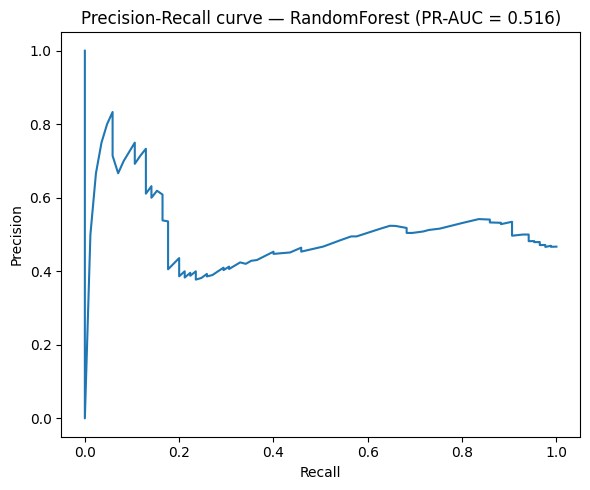

At recall=0.69, precision=0.50, threshold=0.177


In [ ]:
y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
pr_auc_test = average_precision_score(y_test, y_proba_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — {best_model_name} (PR-AUC = {pr_auc_test:.3f})")
plt.tight_layout()
plt.savefig('/content/precision_recall_curve.png', dpi=150)
plt.show()

TARGET_RECALL = 0.7   # <-- adjust this to trade off precision vs recall
idx = np.argmin(np.abs(recalls[:-1] - TARGET_RECALL))  # thresholds has one fewer element than recalls/precisions
chosen_threshold = thresholds[idx]
print(f"At recall={recalls[idx]:.2f}, precision={precisions[idx]:.2f}, threshold={chosen_threshold:.3f}")

In [ ]:
# --- default 0.5 threshold, for reference ---
y_pred_default = (y_proba_test >= 0.5).astype(int)
print("=== Default threshold (0.5) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_default):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_default, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_default, zero_division=0):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred_default, zero_division=0):.3f}")

# --- tuned threshold from the precision-recall curve ---
y_pred = (y_proba_test >= chosen_threshold).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba_test)

print(f"\n=== Tuned threshold ({chosen_threshold:.3f}) ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")
print(f"PR-AUC:    {pr_auc_test:.3f}")
print("\nFull classification report (tuned threshold):\n",
      classification_report(y_test, y_pred, target_names=["Normal", "Pre-arrest"], zero_division=0))

=== Default threshold (0.5) ===
Accuracy:  0.560
Precision: 0.619
Recall:    0.153
F1 score:  0.245

=== Tuned threshold (0.177) ===
Accuracy:  0.538
Precision: 0.504
Recall:    0.694
F1 score:  0.584
ROC-AUC:   0.547
PR-AUC:    0.516

Full classification report (tuned threshold):
               precision    recall  f1-score   support

      Normal       0.60      0.40      0.48        97
  Pre-arrest       0.50      0.69      0.58        85

    accuracy                           0.54       182
   macro avg       0.55      0.55      0.53       182
weighted avg       0.56      0.54      0.53       182



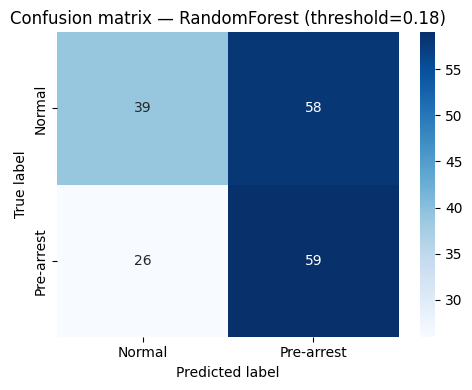

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Pre-arrest"], yticklabels=["Normal", "Pre-arrest"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion matrix — {best_model_name} (threshold={chosen_threshold:.2f})")
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

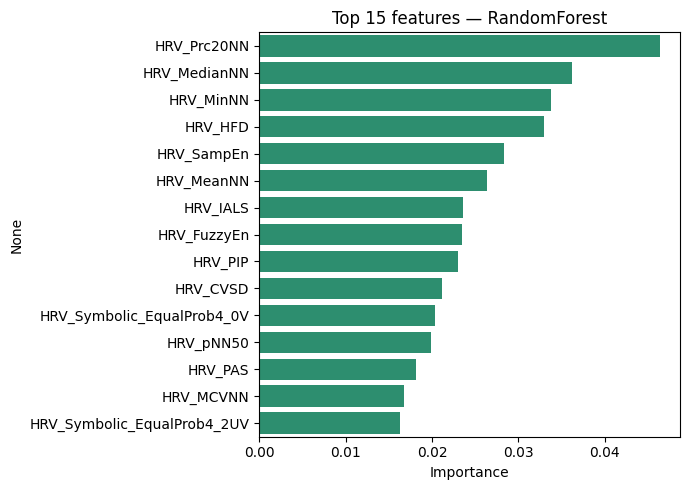

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=keep_cols).sort_values(ascending=False)
    top_features = importances.head(15)

    plt.figure(figsize=(7, 5))
    sns.barplot(x=top_features.values, y=top_features.index, color="#1D9E75")
    plt.xlabel("Importance")
    plt.title(f"Top 15 features — {best_model_name}")
    plt.tight_layout()
    plt.savefig('/content/feature_importance.png', dpi=150)
    plt.show()
else:
    top_features = pd.Series(dtype=float)
    print("Selected model has no feature_importances_ (e.g. Logistic/SVM) — "
          "inspect model.coef_ instead if you want feature-level insight.")

In [ ]:
report_lines = []
report_lines.append("# HRV cardiac-arrest-warning model — training report\n")

report_lines.append("## Dataset")
report_lines.append(f"- Total labeled windows: {len(full_df)} (Normal={sum(full_df['label']==0)}, Pre-arrest={sum(full_df['label']==1)})")
report_lines.append(f"- Train patients: {groups_train.nunique()}, Test patients: {groups.iloc[test_idx].nunique()}")
report_lines.append(f"- Feature count: {len(keep_cols)}")
report_lines.append(f"- Feature list: {', '.join(keep_cols)}\n")

report_lines.append("## Model comparison (5-fold StratifiedGroupKFold CV, ranked by PR-AUC)")
report_lines.append(cv_results_df.to_markdown())
report_lines.append(f"\n**Selected model: {best_model_name}**\n")

report_lines.append("## Decision threshold")
report_lines.append(f"- Target recall: {TARGET_RECALL}")
report_lines.append(f"- Chosen threshold: {chosen_threshold:.3f} (probability >= this = predicted pre-arrest)\n")

report_lines.append("## Held-out test set performance (tuned threshold)")
report_lines.append(f"- Accuracy:  {acc:.3f}")
report_lines.append(f"- Precision: {prec:.3f}")
report_lines.append(f"- Recall:    {rec:.3f}")
report_lines.append(f"- F1 score:  {f1:.3f}")
report_lines.append(f"- ROC-AUC:   {auc:.3f}")
report_lines.append(f"- PR-AUC:    {pr_auc_test:.3f}\n")

report_lines.append("## Confusion matrix (rows=true, cols=predicted; [Normal, Pre-arrest])")
report_lines.append(f"```\n{cm}\n```\n")

if len(top_features):
    report_lines.append("## Top 10 features by importance")
    for feat, val in top_features.head(10).items():
        report_lines.append(f"- {feat}: {val:.4f}")

report_text = "\n".join(report_lines)
print(report_text)

with open('/content/model_report.md', 'w') as f:
    f.write(report_text)

# HRV cardiac-arrest-warning model — training report

## Dataset
- Total labeled windows: 710 (Normal=355, Pre-arrest=355)
- Train patients: 18, Test patients: 7
- Feature count: 90
- Feature list: HRV_MeanNN, HRV_SDNN, HRV_SDANN1, HRV_SDNNI1, HRV_RMSSD, HRV_SDSD, HRV_CVNN, HRV_CVSD, HRV_MedianNN, HRV_MadNN, HRV_MCVNN, HRV_IQRNN, HRV_SDRMSSD, HRV_Prc20NN, HRV_Prc80NN, HRV_pNN50, HRV_pNN20, HRV_MinNN, HRV_MaxNN, HRV_HTI, HRV_TINN, HRV_VLF, HRV_LF, HRV_HF, HRV_VHF, HRV_TP, HRV_LFHF, HRV_LFn, HRV_HFn, HRV_LnHF, HRV_SD1, HRV_SD2, HRV_SD1SD2, HRV_S, HRV_CSI, HRV_CVI, HRV_CSI_Modified, HRV_PIP, HRV_IALS, HRV_PSS, HRV_PAS, HRV_GI, HRV_SI, HRV_AI, HRV_PI, HRV_C1d, HRV_C1a, HRV_SD1d, HRV_SD1a, HRV_C2d, HRV_C2a, HRV_SD2d, HRV_SD2a, HRV_Cd, HRV_Ca, HRV_SDNNd, HRV_SDNNa, HRV_DFA_alpha1, HRV_MFDFA_alpha1_Width, HRV_MFDFA_alpha1_Peak, HRV_MFDFA_alpha1_Mean, HRV_MFDFA_alpha1_Max, HRV_MFDFA_alpha1_Delta, HRV_MFDFA_alpha1_Asymmetry, HRV_MFDFA_alpha1_Fluctuation, HRV_MFDFA_alpha1_Increment, HRV_DFA_alph